# Assignment Module 2: Pet Classification

The goal of this assignment is to implement a neural network that classifies images of 37 breeds of cats and dogs from the [Oxford-IIIT-Pet dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). The assignment is divided into two parts: first, you will be asked to implement from scratch your own neural network for image classification; then, you will fine-tune a pretrained network provided by PyTorch.


## Dataset

The following cells contain the code to download and access the dataset you will be using in this assignment. Note that, although this dataset features each and every image from [Oxford-IIIT-Pet](https://www.robots.ox.ac.uk/~vgg/data/pets/), it uses a different train-val-test split than the original authors.


In [26]:
!git clone https://github.com/CVLAB-Unibo/ipcv-assignment-2.git

In [1]:
import os
import math
import numpy as np
import random
import pandas as pd
from pathlib import Path
from PIL import Image
from torch import Tensor
import torch
from torch.utils.data import Dataset
from typing import List, Tuple
import matplotlib.pyplot as plt
import wandb
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from tqdm.auto import tqdm


BATCH_SIZE = 64

c:\Users\mpred\miniconda3\envs\ipcv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
# Login into wandb
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

In [36]:
# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [39]:
LABELS_TO_NAME = {
    0: "Abyssinian",
    1: "american_bulldog",
    2: "american_pit_bull_terrier",
    3: "basset_hound",
    4: "beagle",
    5: "Bengal",
    6: "Birman",
    7: "Bombay",
    8: "boxer",
    9: "British_Shorthair",
    10: "chihuahua",
    11: "Egyptian_Mau",
    12: "english_cocker_spaniel",
    13: "english_setter",
    14: "german_shorthaired",
    15: "great_pyrenees",
    16: "havanese",
    17: "japanese_chin",
    18: "keeshond",
    19: "leonberger",
    20: "Maine_Coon",
    21: "miniature_pinscher",
    22: "newfoundland",
    23: "Persian",
    24: "pomeranian",
    25: "pug",
    26: "Ragdoll",
    27: "Russian_Blue",
    28: "saint_bernard",
    29: "samoyed",
    30: "scottish_terrier",
    31: "shiba_inu",
    32: "Siamese",
    33: "Sphynx",
    34: "staffordshire_bull_terrier",
    35: "wheaten_terrier",
    36: "yorkshire_terrier",
}

NUM_CLASSES = 37


class OxfordPetDataset(Dataset):
    def __init__(self, split: str, transform=None) -> None:
        super().__init__()

        # self.root = Path("/scratch.hpc/matteo.preda/ipcv-assignment-2") / "dataset"
        self.root = Path("ipcv-assignment-2") / "dataset"
        self.split = split
        self.names, self.labels = self._get_names_and_labels()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[Tensor, int]:
        img_path = self.root / "images" / f"{self.names[idx]}.jpg"
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

    def get_num_classes(self) -> int:
        return max(self.labels) + 1

    def _get_names_and_labels(self) -> Tuple[List[str], List[int]]:
        names = []
        labels = []

        with open(self.root / "annotations" / f"{self.split}.txt") as f:
            for line in f:
                name, label = line.replace("\n", "").split(" ")
                names.append(name),
                labels.append(int(label) - 1)

        return names, labels

## Data Inspection


In [ ]:
# Optimized transforms for GPU training
train_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# No augmentation for val/test, but still resize and normalize
val_test_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_dataset = OxfordPetDataset("train", transform=train_transform)
val_dataset = OxfordPetDataset("val", transform=val_test_transform)
test_dataset = OxfordPetDataset("test", transform=val_test_transform)

# Optimized DataLoaders for GPU training
train_dl = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
)
val_dl = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
)
test_dl = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)

The train dataset contains 3669
The test dataset contains 1834
The train dataset contains 1846


The train dataset contains 3669
The test dataset contains 1834
The train dataset contains 1846


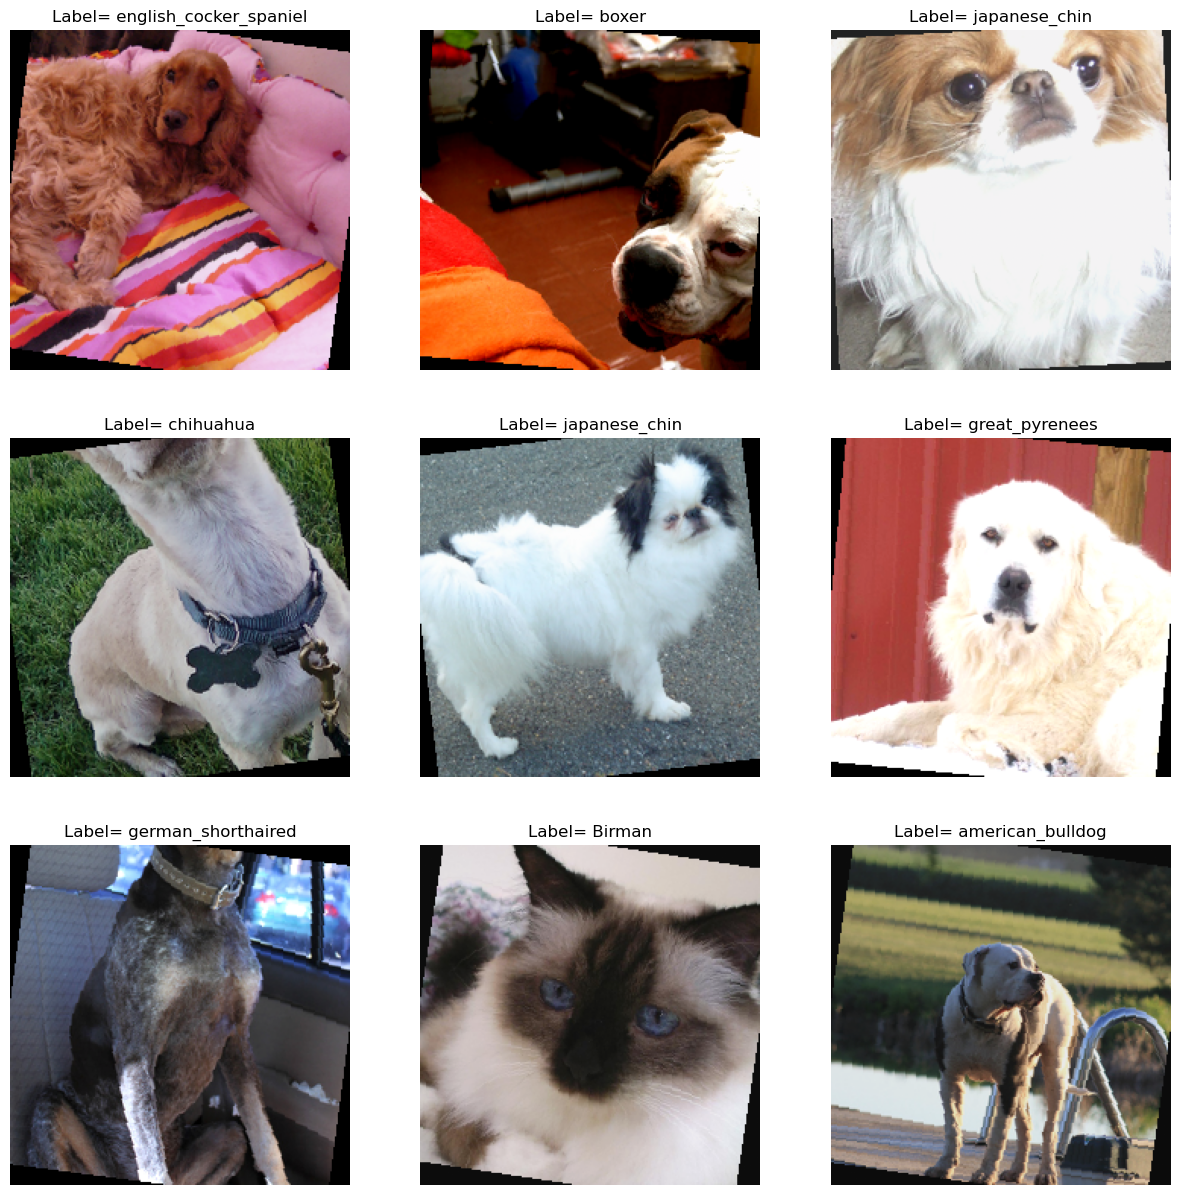

In [42]:
def denorm_image(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """
    Denormalize a tensor image (C, H, W) or (B, C, H, W) that was normalized
    using torchvision's Normalize(mean, std).
    """
    if tensor.ndim == 3:
        mean = torch.tensor(mean, device=tensor.device).view(-1, 1, 1)
        std = torch.tensor(std, device=tensor.device).view(-1, 1, 1)
    elif tensor.ndim == 4:
        mean = torch.tensor(mean, device=tensor.device).view(1, -1, 1, 1)
        std = torch.tensor(std, device=tensor.device).view(1, -1, 1, 1)
    else:
        raise ValueError("Expected tensor of shape (C,H,W) or (B,C,H,W)")

    return tensor * std + mean


print(f"The train dataset contains {len(train_dataset)}")
print(f"The test dataset contains {len(val_dataset)}")
print(f"The train dataset contains {len(test_dataset)}")
indexes = torch.randperm(len(train_dataset))[:9]
plt.figure(figsize=(15, 15))
for ind, i in enumerate(indexes):
    img, label = train_dataset[i]
    plt.subplot(3, 3, ind + 1)
    plt.imshow(denorm_image(img).permute(1, 2, 0))
    plt.title(f"Label= {LABELS_TO_NAME[label]}")
    plt.axis("off")

## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `OxfordPetDataset`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~60%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an _ablation study_ to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~60% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

### Architecture Overview

This notebook implements a custom **EfficientNet-inspired neural network** built from scratch.

### Rationale for choosing an EfficientNet‑inspired architecture

- EfficientNet uses a principled compound scaling of depth, width and input resolution to maximize accuracy per parameter and per FLOP, providing an excellent accuracy/efficiency trade‑off for resource‑constrained training and inference (Tan & Le, 2019).
- The architecture builds on efficient building blocks (MBConv / inverted residuals) that preserve representational power with low computational cost (Sandler et al., 2018), and integrates channel attention (Squeeze‑and‑Excitation) to improve feature discrimination when useful (Hu et al., 2018).
- Modern activations (e.g., Swish) and stochastic regularization techniques used in EfficientNet have been shown to improve optimization and generalization in deep ConvNets, beneficial for fine‑grained classification tasks with limited data (Ramachandran et al., 2017; Huang et al., 2016).
- Overall, an EfficientNet‑inspired design provides a compact, well‑regularized baseline that is straightforward to scale and to ablate (remove SE, BN, etc.), making it well suited for systematic experimental analysis on the Oxford‑IIIT Pet fine‑grained classification problem.

References

- Tan, M. & Le, Q. V. EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks. ICML 2019. arXiv:1905.11946
- Sandler, M., Howard, A., Zhu, M., Zhmoginov, A. & Chen, L. MobileNetV2: Inverted Residuals and Linear Bottlenecks. CVPR 2018. arXiv:1801.04381
- Hu, J., Shen, L. & Sun, G. Squeeze-and-Excitation Networks. CVPR 2018. arXiv:1709.01507
- Ramachandran, P., Zoph, B. & Le, Q. V. Searching for Activation Functions. arXiv:1710.05941 (2017)
- Huang, G., Sun, Y., Liu, Z., Sedra, D. & Weinberger, K. Q. Deep Networks with Stochastic Depth. ECCV 2016. arXiv:1603.09382

The architecture is composed of several key components:

#### **Building Blocks:**

1. **Swish Activation (SiLU)**: A smooth, non-linear activation function defined as $x \cdot \sigma(x)$, which has been shown to outperform ReLU in many modern architectures.

2. **Squeeze-and-Excitation (SE) Block**: A channel attention mechanism that:

   - Applies global average pooling to compress spatial information
   - Uses two 1×1 convolutions to learn channel-wise relationships
   - Re-scales feature maps by learned channel importance weights
   - Helps the network focus on the most informative channels

3. **DropConnect (Stochastic Depth)**: A regularization technique that randomly drops entire residual connections during training with linearly increasing probability, promoting network robustness and enabling training of deeper models.

4. **MBConvBlock (Mobile Inverted Bottleneck Convolution)**: The core building block with:
   - **Expansion phase**: Increases channels via 1×1 convolution to learn in higher-dimensional space
   - **Depthwise separable convolution**: Applies spatial convolution per-channel (depthwise) followed by channel mixing (pointwise)
   - **Squeeze-Excitation module**: Channel attention applied after spatial operations
   - **Projection phase**: Reduces channels back via 1×1 convolution
   - **Skip connections**: Residual paths when dimensions match, with optional DropConnect regularization

#### **Main Network:**

**EfficientNetCustom** class implements a scalable EfficientNet architecture with:

- **Stem**: Initial 3×3 convolution layer that downsamples input by 2× and processes raw image data
- **Seven MBConv stages**: Progressive feature extraction with:
  - Stage 1-7 with varying expansion ratios (1 or 6), output channels (16-320), and kernel sizes
  - Configurable width/depth scaling via coefficients for model variants (B0, B1, B2)
  - Linearly increasing stochastic depth to encourage shallower paths early in training
- **Head**: Classification layers with:
  - 1×1 convolution expansion to 1280 channels
  - Optional batch normalization
  - Configurable pooling (average or max) for spatial aggregation
  - Dropout for regularization
  - Final linear layer for 37-class pet breed classification


## Block definition for the net


In [ ]:
class Swish(nn.Module):
    """Swish activation function (SiLU)"""

    def forward(self, x):
        return x * torch.sigmoid(x)


class SqueezeExcitation(nn.Module):
    """Squeeze-and-Excitation block for channel attention"""

    def __init__(self, in_channels: int, reduced_dim: int):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, reduced_dim, 1),
            Swish(),
            nn.Conv2d(reduced_dim, in_channels, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.se(x)


class DropConnect(nn.Module):
    """Stochastic depth (drop connect) for regularization"""

    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0:
            return x

        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()
        return x.div(keep_prob) * random_tensor


class MBConvBlock(nn.Module):
    """Mobile Inverted Bottleneck Convolution Block with SE"""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        stride: int,
        expand_ratio: int,
        se_ratio: float = 0.25,
        drop_connect_rate: float = 0.0,
        use_se: bool = True,
        use_swish: bool = True,
    ):
        super().__init__()
        self.stride = stride
        self.use_residual = stride == 1 and in_channels == out_channels
        self.use_se = use_se

        # Choose activation function
        activation = Swish() if use_swish else nn.ReLU(inplace=True)

        # Expansion phase
        expanded_channels = in_channels * expand_ratio
        self.expand = expand_ratio != 1

        if self.expand:
            self.expansion_conv = nn.Sequential(
                nn.Conv2d(in_channels, expanded_channels, 1, bias=False),
                nn.BatchNorm2d(expanded_channels),
                activation,
            )

        # Depthwise separable convolution
        self.depthwise_conv = nn.Sequential(
            nn.Conv2d(
                expanded_channels,
                expanded_channels,
                kernel_size,
                stride=stride,
                padding=kernel_size // 2,
                groups=expanded_channels,  # Depthwise
                bias=False,
            ),
            nn.BatchNorm2d(expanded_channels),
            activation,
        )

        # Squeeze and Excitation (optional)
        if use_se:
            se_channels = max(1, int(in_channels * se_ratio))
            self.se = SqueezeExcitation(expanded_channels, se_channels)
        else:
            self.se = nn.Identity()

        # Output projection
        self.project = nn.Sequential(
            nn.Conv2d(expanded_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

        self.drop_connect = DropConnect(drop_connect_rate)

    def forward(self, x):
        identity = x

        if self.expand:
            x = self.expansion_conv(x)

        x = self.depthwise_conv(x)
        x = self.se(x)
        x = self.project(x)

        if self.use_residual:
            x = self.drop_connect(x)
            x = x + identity

        return x

## Net definition and variation


In [ ]:
class EfficientNetCustom(nn.Module):
    """Custom EfficientNet-inspired model built from scratch"""

    def __init__(
        self,
        num_classes: int = 37,
        width_coefficient: float = 1.0,
        depth_coefficient: float = 1.0,
        dropout_rate: float = 0.2,
        drop_connect_rate: float = 0.2,
        image_size: int = 224,
        use_se: bool = True,
        use_swish: bool = True,
        use_batch_norm: bool = True,
        pooling_type: str = "avg",
    ):
        super().__init__()
        self.use_batch_norm = use_batch_norm
        self.pooling_type = pooling_type

        # EfficientNet block configuration
        # Format: [expand_ratio, out_channels, num_blocks, stride, kernel_size]
        base_config = [
            [1, 16, 1, 1, 3],  # Stage 1
            [6, 24, 2, 2, 3],  # Stage 2
            [6, 40, 2, 2, 5],  # Stage 3
            [6, 80, 3, 2, 3],  # Stage 4
            [6, 112, 3, 1, 5],  # Stage 5
            [6, 192, 4, 2, 5],  # Stage 6
            [6, 320, 1, 1, 3],  # Stage 7
        ]

        # Scaling functions
        def scale_width(channels):
            return int(math.ceil(channels * width_coefficient / 8) * 8)

        def scale_depth(num_blocks):
            return int(math.ceil(num_blocks * depth_coefficient))

        # Choose activation function
        activation = Swish() if use_swish else nn.ReLU(inplace=True)

        # Stem: initial convolution
        out_channels = scale_width(32)
        self.stem = nn.Sequential(
            nn.Conv2d(3, out_channels, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            activation,
        )

        # Build MBConv stages
        blocks = []
        total_blocks = sum([scale_depth(config[2]) for config in base_config])
        block_idx = 0

        in_channels = out_channels
        for expand_ratio, channels, num_blocks, stride, kernel_size in base_config:
            out_channels = scale_width(channels)
            num_blocks = scale_depth(num_blocks)

            for i in range(num_blocks):
                # Linearly increase drop connect rate
                drop_rate = drop_connect_rate * block_idx / total_blocks

                blocks.append(
                    MBConvBlock(
                        in_channels=in_channels,
                        out_channels=out_channels,
                        kernel_size=kernel_size,
                        stride=stride if i == 0 else 1,
                        expand_ratio=expand_ratio,
                        se_ratio=0.25,
                        drop_connect_rate=drop_rate,
                        use_se=use_se,
                        use_swish=use_swish,
                    )
                )
                in_channels = out_channels
                block_idx += 1

        self.blocks = nn.Sequential(*blocks)

        # Head: final classification layers
        head_channels = scale_width(1280)

        head_layers = [
            nn.Conv2d(in_channels, head_channels, 1, bias=False),
        ]
        if use_batch_norm:
            head_layers.append(nn.BatchNorm2d(head_channels))
        head_layers.append(activation)

        # Add pooling layer
        if pooling_type == "avg":
            head_layers.append(nn.AdaptiveAvgPool2d(1))
        elif pooling_type == "max":
            head_layers.append(nn.AdaptiveMaxPool2d(1))
        else:
            raise ValueError(f"Unknown pooling_type: {pooling_type}")

        head_layers.extend(
            [
                nn.Flatten(),
                nn.Dropout(dropout_rate),
                nn.Linear(head_channels, num_classes),
            ]
        )
        self.head = nn.Sequential(*head_layers)

        self._initialize_weights()

    def _initialize_weights(self):
        """Initialize network weights"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        return x

## Model factory functions


In [ ]:
def create_efficientnet_b0(
    num_classes: int = 37,
    use_se: bool = True,
    use_swish: bool = True,
    use_batch_norm: bool = True,
    pooling_type: str = "avg",
):
    """EfficientNet-B0: baseline model"""
    return EfficientNetCustom(
        num_classes=num_classes,
        width_coefficient=1.0,
        depth_coefficient=1.0,
        dropout_rate=0.2,
        drop_connect_rate=0.2,
        use_se=use_se,
        use_swish=use_swish,
        use_batch_norm=use_batch_norm,
        pooling_type=pooling_type,
    )


def create_efficientnet_b1(
    num_classes: int = 37,
    use_se: bool = True,
    use_swish: bool = True,
    use_batch_norm: bool = True,
    pooling_type: str = "avg",
):
    """EfficientNet-B1: slightly larger"""
    return EfficientNetCustom(
        num_classes=num_classes,
        width_coefficient=1.0,
        depth_coefficient=1.1,
        dropout_rate=0.2,
        drop_connect_rate=0.2,
        use_se=use_se,
        use_swish=use_swish,
        use_batch_norm=use_batch_norm,
        pooling_type=pooling_type,
    )


def create_efficientnet_b2(
    num_classes: int = 37,
    use_se: bool = True,
    use_swish: bool = True,
    dropout_rate: float = 0.4,
    drop_connect_rate: float = 0.2,
    use_batch_norm: bool = True,
    pooling_type: str = "avg",
):
    """EfficientNet-B2: medium size"""
    return EfficientNetCustom(
        num_classes=num_classes,
        width_coefficient=1.1,
        depth_coefficient=1.2,
        dropout_rate=dropout_rate,
        drop_connect_rate=drop_connect_rate,
        use_se=use_se,
        use_swish=use_swish,
        use_batch_norm=use_batch_norm,
        pooling_type=pooling_type,
    )


def count_parameters(model):
    """Count trainable parameters in model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Model tests


In [ ]:
print("Testing EfficientNet Custom Implementation\n")
print("=" * 60)

# Test model creation
model_b0 = create_efficientnet_b0(NUM_CLASSES)
model_b1 = create_efficientnet_b1(NUM_CLASSES)
model_b2 = create_efficientnet_b2(NUM_CLASSES)

# Print parameter counts
models_info = {
    "EfficientNet-B0": model_b0,
    "EfficientNet-B1": model_b1,
    "EfficientNet-B2": model_b2,
}

for name, model in models_info.items():
    params = count_parameters(model)
    print(f"{name:30s}: {params:,} parameters")

print("=" * 60)

# Test forward pass
test_input = torch.randn(2, 3, 224, 224)
test_output = model_b0(test_input)
print(f"\nForward pass test:")
print(f"  Input shape:  {test_input.shape}")
print(f"  Output shape: {test_output.shape}")
print(
    f"  Output range: [{test_output.min().item():.3f}, {test_output.max().item():.3f}]"
)

Testing EfficientNet Custom Implementation

EfficientNet-B0               : 4,054,945 parameters
EfficientNet-B1               : 6,560,581 parameters
EfficientNet-B2               : 8,174,061 parameters

Forward pass test:
  Input shape:  torch.Size([2, 3, 224, 224])
  Output shape: torch.Size([2, 37])
  Output range: [-0.219, 0.214]


## Train and Test function


In [ ]:
def train_efficientnet(
    model: torch.nn.Module,
    dl_train,
    dl_val,
    criterion,
    optimizer,
    scheduler,
    epochs: int,
    device: str = "cpu",
    save_dir: str = "./checkpoints",
    use_amp: bool = True,
    grad_clip: float = 1.0,
    learning_rate: float = None,
    use_wandb: bool = False,
    name: str = None,
    run_name: str = None,
    entity: str = None,
    project: str = None,
):
    """
    Args:
        learning_rate: If provided, will override optimizer's initial learning rate
    """
    if use_wandb:
        wandb.init(
            project=project,
            name=run_name,
            entity=entity,
            config={
                "epochs": epochs,
                "optimizer": optimizer.__class__.__name__,
                "scheduler": scheduler.__class__.__name__ if scheduler else "None",
                "criterion": criterion.__class__.__name__,
                "device": device,
                "model": model.__class__.__name__,
                "use_amp": use_amp,
                "grad_clip": grad_clip,
                "learning_rate": (
                    learning_rate if learning_rate else optimizer.defaults["lr"]
                ),
            },
        )

    # Override learning rate if provided
    if learning_rate is not None:
        for param_group in optimizer.param_groups:
            param_group["lr"] = learning_rate

    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(os.path.join(save_dir, name), exist_ok=True)

    model.to(device)
    scaler = torch.cuda.amp.GradScaler() if use_amp and device == "cuda" else None

    best_val_acc = 0.0
    global_step = 0

    for e in tqdm(range(epochs), desc="Training"):
        # Training phase
        model.train()
        running_loss = 0.0

        for images, labels in dl_train:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            # Mixed precision forward pass
            if use_amp and scaler:
                with torch.cuda.amp.autocast():
                    output_logits = model(images)
                    loss = criterion(output_logits, labels)

                scaler.scale(loss).backward()

                # Gradient clipping
                if grad_clip > 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

                scaler.step(optimizer)
                scaler.update()
            else:
                output_logits = model(images)
                loss = criterion(output_logits, labels)
                loss.backward()

                if grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

                optimizer.step()

            running_loss += loss.item()
            global_step += 1

            if global_step % 10 == 0:
                if use_wandb:
                    wandb.log({"train_loss_step": loss.item()}, step=global_step)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in dl_val:
                images, labels = images.to(device), labels.to(device)

                if use_amp and device == "cuda":
                    with torch.cuda.amp.autocast():
                        output_logits = model(images)
                        loss = criterion(output_logits, labels)
                else:
                    output_logits = model(images)
                    loss = criterion(output_logits, labels)

                val_loss += loss.item()
                pred_labels = output_logits.argmax(1)
                correct += (pred_labels == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = val_loss / len(dl_val)
        val_accuracy = correct / total

        # Learning rate scheduling
        if scheduler:
            scheduler.step()
            current_lr = scheduler.get_last_lr()[0]
            if use_wandb:
                wandb.log({"learning_rate": current_lr}, step=global_step)

        if use_wandb:
            # Logging
            wandb.log(
                {
                    "val_loss_epoch": avg_val_loss,
                    "val_accuracy": val_accuracy,
                    "epoch": e + 1,
                },
                step=global_step,
            )

        # Save best model
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            best_path = os.path.join(save_dir, name, "best_model.pt")
            torch.save(model.state_dict(), best_path)
            if use_wandb:
                wandb.run.summary["best_val_accuracy"] = best_val_acc
            print(f"\nSaved best model (epoch {e+1}, acc={best_val_acc:.4f})")

    if use_wandb:
        wandb.finish()


def test(
    model: torch.nn.Module,
    dl_test,
    criterion,
    checkpoint_path: str,
    device: str = "cpu",
    use_wandb: bool = False,
    project: str = None,
    run_name: str = None,
    entity: str = None,
):
    """
    Evaluate a trained model on the test set and compute performance metrics.
    """
    if use_wandb:
        # Initialize W&B
        wandb.init(
            project=project,
            name=run_name,
            entity=entity,
            job_type="test",
            config={
                "device": device,
                "model": model.__class__.__name__,
                "checkpoint": checkpoint_path,
            },
        )

    # Load model checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    if "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()

    # Accumulators
    test_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dl_test:
            images, labels = images.to(device), labels.to(device)
            output_logits = model(images)
            loss = criterion(output_logits, labels)
            test_loss += loss.item()

            preds = output_logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Average loss
    avg_test_loss = test_loss / len(dl_test)

    # Metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    # Print report
    print("\n=== Test Results ===")
    print(f"Loss: {avg_test_loss:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))

    if use_wandb:
        # Log metrics to W&B
        wandb.log(
            {
                "test_loss": avg_test_loss,
                "test_accuracy": acc,
                "test_precision": prec,
                "test_recall": rec,
                "test_f1": f1,
                "confusion_matrix": wandb.plot.confusion_matrix(
                    probs=None,
                    y_true=all_labels,
                    preds=all_preds,
                    title="Confusion Matrix",
                ),
            }
        )

        wandb.finish()

    return {
        "test_loss": avg_test_loss,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm,
    }

# Training hyperparameters


In [48]:
EPOCHS = 150
LR = 1e-3
WEIGHT_DECAY = 1e-3
CRITERION = nn.CrossEntropyLoss()

# Train


In [ ]:
for model_name, model in models_info.items():
    print(f"Training {model_name}...")

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    train_efficientnet(
        model=model,
        dl_train=train_dl,
        dl_val=val_dl,
        criterion=CRITERION,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=EPOCHS,
        name=model_name,
        device="cuda",
        run_name=f"{model_name}_run",
        save_dir="./weights/checkpoints",
        use_amp=True,
        grad_clip=1.0,
        use_wandb=False,
    )

In [ ]:
train_df = pd.read_csv("train.csv", sep=";")

# Filter val_accuracy to show only B0, B1, B2 models and get maximum accuracy
check_rows = ["EfficientNet-B0_run", "EfficientNet-B1_run", "EfficientNet-B2_run"]
base_models_df = train_df.where(train_df["run_name"].isin(check_rows))
# Get only the maximum val_accuracy for each model
base_models_df = base_models_df[["run_name", "best_val_accuracy"]].dropna()

base_models_df

,run_name,best_val_accuracy
8,EfficientNet-B2_run,0.685932
9,EfficientNet-B1_run,0.662486
10,EfficientNet-B0_run,0.677208


# Test


In [ ]:
for model_name, model in models_info.items():
    print(f"\nTesting {model_name}...")
    test_metrics = test(
        model,
        dl_test=test_dl,
        criterion=CRITERION,
        checkpoint_path=f"./weights/checkpoints/{model_name}/best_model.pt",
        use_wandb=False,
    )

    print(f"\nTest Results for {model_name}:")
    print(f"  Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"  Precision: {test_metrics['precision']:.4f}")
    print(f"  Recall:    {test_metrics['recall']:.4f}")
    print(f"  F1 Score:  {test_metrics['f1']:.4f}")

In [ ]:
test_df = pd.read_csv("test.csv", sep=";").drop(columns=["Unnamed: 8", "Unnamed: 9"])

# Filter to show only B0, B1, B2 models
check_rows = ["EfficientNet-B0_test", "EfficientNet-B1_test", "EfficientNet-B2_test"]
base_models_df = test_df.where(test_df["run_name"].isin(check_rows)).dropna()

base_models_df

,run_name,runtime (s),device,test_accuracy,test_f1,test_loss,test_precision,test_recall
8,EfficientNet-B2_test,115.0,cpu,0.715601,0.714166,1.493587,0.717456,0.715601
9,EfficientNet-B1_test,63.0,cpu,0.697183,0.695306,1.629662,0.700818,0.697183
10,EfficientNet-B0_test,59.0,cpu,0.697725,0.696397,1.636053,0.699840,0.697725


## Evaluation

The training and test experiments establish that EfficientNet-B2 achieves superior performance relative to the B0 and B1 baseline models. The ablation study that follows was therefore conducted solely on the EfficientNet-B2 architecture


## Definition of all the experiments to perform the ablation study


### Ablation Study

#### **Baseline Model: EfficientNet-B2 (Full Configuration)**

- Squeeze-Excitation blocks
- Swish activation function
- DropConnect regularization
- Batch Normalization
- Average pooling
- Data augmentation
- Learning rate: 1e-3

#### **Ablation Experiments & Justification:**

| Experiment            | Modification                                                       | Motivation                                                                                                                                                                                                                                                                    |
| --------------------- | ------------------------------------------------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **B2-No-SE**          | Remove Squeeze-Excitation blocks                                   | Quantifies the benefit of **channel attention**. SE blocks enable the network to adaptively re-weight feature channels, which could improve fine-grained discrimination between pet breeds. Removing them tests if attention mechanisms are essential or redundant.           |
| **B2-No-Swish**       | Replace Swish with ReLU activation                                 | Evaluates the impact of the **activation function choice**. Swish is a smooth, learnable activation that's more computationally expensive than ReLU. This experiment tests whether the improved expressiveness justifies the computational cost for this classification task. |
| **B2-No-DropConnect** | Remove stochastic depth regularization                             | Assesses the role of **DropConnect in preventing overfitting**. This random connection dropout during training encourages ensemble-like behavior. Its removal tests if it's critical for generalization or if standard dropout is sufficient.                                 |
| **B2-No-BatchNorm**   | Disable batch normalization of the network head                    | **Batch normalization** stabilizes training and rescales features in the head; we ablate it to test whether this is truly necessary or redundant given normalization already applied in earlier blocks.                                                                       |
| **B2-HighLR**         | Increase learning rate from 1e-3 to 5e-3                           | Explores **learning rate sensitivity**. Higher learning rates risk divergence but may lead to better minima discovery. This tests the robustness of the architecture to training hyperparameters.                                                                             |
| **B2-LowLR**          | Decrease learning rate from 1e-3 to 1e-4                           | Evaluates if **slower learning improves final accuracy**. Lower learning rates enable more careful optimization but require more epochs. This tests whether our baseline learning rate is optimal or if slower convergence helps.                                             |
| **B2-MaxPool**        | Replace average pooling with max pooling                           | Investigates **spatial aggregation strategy**. Average pooling preserves spatial information while max pooling emphasizes peak activations. Different pooling strategies may benefit different feature types.                                                                 |
| **B2-NoAugmentation** | Disable data augmentation (no random crop, rotation, color jitter) | Quantifies the **regularization effect of data augmentation**. Augmentation increases training set diversity, reducing overfitting. This experiment tests if strong augmentation is necessary or if the model generalizes without it.                                         |

#### **Experimental Setup:**

- All ablations use **EfficientNet-B2 architecture** as the baseline
- Single component changes at a time
- Same training procedure: 150 epochs, AdamW optimizer, cosine annealing scheduler
- Validation metrics tracked: accuracy, precision, recall, F1-score
- Test set evaluation for final performance assessment


In [ ]:
# Create datasets without augmentation for ablation study
no_augmentation_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_dataset_no_aug = OxfordPetDataset("train", transform=no_augmentation_transform)
train_dl_no_aug = DataLoader(
    train_dataset_no_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True,
)

ablation_configs = {
    "B2-No-SE": {
        "use_se": False,
        "use_swish": True,
        "dropout_rate": 0.4,
        "drop_connect_rate": 0.2,
        "use_batch_norm": True,
        "learning_rate": 1e-3,
        "pooling_type": "avg",
        "use_data_augmentation": True,
        "description": "Without Squeeze-Excitation blocks",
    },
    "B2-No-Swish": {
        "use_se": True,
        "use_swish": False,
        "dropout_rate": 0.4,
        "drop_connect_rate": 0.2,
        "use_batch_norm": True,
        "learning_rate": 1e-3,
        "pooling_type": "avg",
        "use_data_augmentation": True,
        "description": "With ReLU instead of Swish activation",
    },
    "B2-No-DropConnect": {
        "use_se": True,
        "use_swish": True,
        "dropout_rate": 0.4,
        "drop_connect_rate": 0.0,
        "use_batch_norm": True,
        "learning_rate": 1e-3,
        "pooling_type": "avg",
        "use_data_augmentation": True,
        "description": "Without stochastic depth (drop connect)",
    },
    "B2-No-BatchNorm": {
        "use_se": True,
        "use_swish": True,
        "dropout_rate": 0.4,
        "drop_connect_rate": 0.2,
        "use_batch_norm": False,
        "learning_rate": 1e-3,
        "pooling_type": "avg",
        "use_data_augmentation": True,
        "description": "Without Batch Normalization",
    },
    "B2-HighLR": {
        "use_se": True,
        "use_swish": True,
        "dropout_rate": 0.4,
        "drop_connect_rate": 0.2,
        "use_batch_norm": True,
        "learning_rate": 5e-3,
        "pooling_type": "avg",
        "use_data_augmentation": True,
        "description": "Higher learning rate (5e-3 instead of 1e-3)",
    },
    "B2-LowLR": {
        "use_se": True,
        "use_swish": True,
        "dropout_rate": 0.4,
        "drop_connect_rate": 0.2,
        "use_batch_norm": True,
        "learning_rate": 1e-4,
        "pooling_type": "avg",
        "use_data_augmentation": True,
        "description": "Lower learning rate (1e-4 instead of 1e-3)",
    },
    "B2-MaxPool": {
        "use_se": True,
        "use_swish": True,
        "dropout_rate": 0.4,
        "drop_connect_rate": 0.2,
        "use_batch_norm": True,
        "learning_rate": 1e-3,
        "pooling_type": "max",
        "use_data_augmentation": True,
        "description": "Max pooling instead of average pooling",
    },
    "B2-NoAugmentation": {
        "use_se": True,
        "use_swish": True,
        "dropout_rate": 0.4,
        "drop_connect_rate": 0.2,
        "use_batch_norm": True,
        "learning_rate": 1e-3,
        "pooling_type": "avg",
        "use_data_augmentation": False,
        "description": "No data augmentation (no rotation, color jitter, random crop)",
    },
}


def create_ablation_model(config_name, num_classes=37):
    """Create an EfficientNet-B2 model with ablation settings"""
    config = ablation_configs[config_name]
    return create_efficientnet_b2(
        num_classes=num_classes,
        use_se=config["use_se"],
        use_swish=config["use_swish"],
        dropout_rate=config["dropout_rate"],
        drop_connect_rate=config["drop_connect_rate"],
        use_batch_norm=config["use_batch_norm"],
        pooling_type=config["pooling_type"],
    )


def get_training_config(config_name):
    """Extract training-specific configuration"""
    config = ablation_configs[config_name]
    return {
        "learning_rate": config["learning_rate"],
        "use_data_augmentation": config["use_data_augmentation"],
    }


def get_ablation_dataloader(config_name, dl_augmented, dl_no_augmented):
    """Return correct dataloader based on ablation config"""
    config = ablation_configs[config_name]
    if config["use_data_augmentation"]:
        return dl_augmented
    else:
        return dl_no_augmented

In [ ]:
def train_ablation_model(
    config_name,
    dl_train_aug,
    dl_train_no_aug,
    dl_val,
    criterion,
    num_classes,
    epochs,
    device,
    save_dir,
    use_wandb: bool = False,
    entity=None,
    project=None,
):
    """Train a model for ablation study with correct dataloader and learning rate"""

    # Get training config
    training_cfg = get_training_config(config_name)

    # Select correct dataloader
    dl_train = get_ablation_dataloader(config_name, dl_train_aug, dl_train_no_aug)

    # Create model
    model = create_ablation_model(config_name, num_classes)

    # Setup optimizer with the correct learning rate
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=training_cfg["learning_rate"], weight_decay=1e-3
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Train
    train_efficientnet(
        model=model,
        dl_train=dl_train,
        dl_val=dl_val,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=epochs,
        device=device,
        save_dir=save_dir,
        use_amp=True,
        grad_clip=1.0,
        learning_rate=training_cfg["learning_rate"],
        use_wandb=use_wandb,
        name=config_name,
        run_name=f"{config_name}_run",
        entity=entity,
        project=project,
    )

    return model

In [ ]:
def test_ablation_model(
    config_name,
    checkpoint_path: str,
    dl_test,
    criterion,
    device,
    use_wandb: bool = False,
    project: str = None,
    run_name: str = None,
    entity: str = None,
):
    """Test a model for ablation study using the correct checkpoint"""

    model = create_ablation_model(config_name)

    test_metrics = test(
        model,
        dl_test=dl_test,
        criterion=criterion,
        checkpoint_path=checkpoint_path,
        device=device,
        use_wandb=use_wandb,
        project=project,
        run_name=run_name,
        entity=entity,
    )

    return test_metrics

In [ ]:
for config_name in ablation_configs.keys():
    print(f"\n{'='*70}")
    print(f"Training: {config_name}")
    print(f"{'='*70}")

    model = train_ablation_model(
        config_name=config_name,
        dl_train_aug=train_dl,  # DataLoader with augmentation
        dl_train_no_aug=train_dl_no_aug,  # DataLoader without augmentation
        dl_val=val_dl,
        criterion=CRITERION,
        num_classes=NUM_CLASSES,
        epochs=EPOCHS,
        device="cuda",
        save_dir="./weights/checkpoints_ablation",
        use_wandb=False,
    )

In [ ]:
for config_name in ablation_configs.keys():

    print(f"\nTesting: {config_name}")
    model = create_ablation_model(config_name)

    test_metrics = test(
        model,
        dl_test=test_dl,
        criterion=CRITERION,
        checkpoint_path=f"./weights/checkpoints_ablation/{config_name}/best_model.pt",
        device="cpu",
        use_wandb=False,
    )

    print(f"\n{'='*70}")
    print(f"Results for {config_name}:")
    print(f"  Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"  Precision: {test_metrics['precision']:.4f}")
    print(f"  Recall:    {test_metrics['recall']:.4f}")
    print(f"  F1 Score:  {test_metrics['f1']:.4f}")
    print(f"{'='*70}\n")

## Training summary for all the models


In [4]:
train_df

,run_name,runtime (s),criterion,device,epochs,grad_clip,learning_rate,optimizer,scheduler,best_val_accuracy,train_loss_step
0,B2-NoAugmentation_run,2081,CrossEntropyLoss,cuda,150,1,0.0010,AdamW,CosineAnnealingLR,0.341330,0.001916
1,B2-MaxPool_run,2504,CrossEntropyLoss,cuda,150,1,0.0010,AdamW,CosineAnnealingLR,0.636314,0.183448
2,B2-LowLR_run,2463,CrossEntropyLoss,cuda,150,1,0.0001,AdamW,CosineAnnealingLR,0.502726,0.843262
3,B2-HighLR_run,2682,CrossEntropyLoss,cuda,150,1,0.0050,AdamW,CosineAnnealingLR,0.604144,0.131840
4,B2-No-BatchNorm_run,2407,CrossEntropyLoss,cuda,150,1,0.0010,AdamW,CosineAnnealingLR,0.714286,0.260767
5,B2-No-DropConnect_run,2422,CrossEntropyLoss,cuda,150,1,0.0010,AdamW,CosineAnnealingLR,0.693021,0.001751
6,B2-No-Swish_run,2344,CrossEntropyLoss,cuda,150,1,0.0010,AdamW,CosineAnnealingLR,0.676663,0.124840
7,B2-No-SE_run,2353,CrossEntropyLoss,cuda,150,1,0.0010,AdamW,CosineAnnealingLR,0.724100,0.055529
8,EfficientNet-B2_run,2429,CrossEntropyLoss,cuda,150,1,0.0010,AdamW,CosineAnnealingLR,0.685932,0.191621
9,EfficientNet-B1_run,2452,CrossEntropyLoss,cuda,150,1,0.0010,AdamW,CosineAnnealingLR,0.662486,0.029643


## Results plots


In [ ]:
val_accuracy = pd.read_csv("val_accuracy.csv", sep=";", index_col=0).dropna(axis=0)
train_loss_step = pd.read_csv("train_loss_step.csv", index_col=0).dropna(axis=0)

# Drop MIN/MAX columns
for col_name in val_accuracy.columns:
    if "MIN" in col_name or "MAX" in col_name:
        val_accuracy = val_accuracy.drop(columns=[col_name])

for col_name in train_loss_step.columns:
    if "MIN" in col_name or "MAX" in col_name:
        train_loss_step = train_loss_step.drop(columns=[col_name])

# Remove " - val_accuracy" from column names
val_accuracy = val_accuracy.rename(
    columns=lambda x: x.replace(" - val_accuracy", "") if " - val_accuracy" in x else x
)
train_loss_step = train_loss_step.rename(
    columns=lambda x: (
        x.replace(" - train_loss_step", "") if " - train_loss_step" in x else x
    )
)

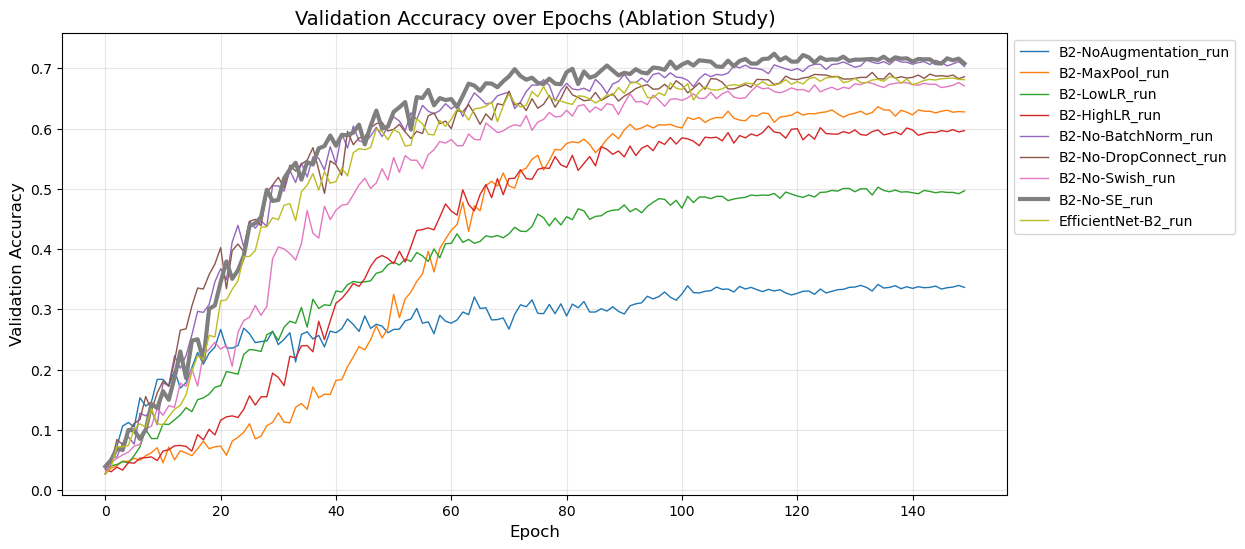

In [ ]:
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111)

# Exclude B0 and B1 models
exclude_cols = ["EfficientNet-B0_run", "EfficientNet-B1_run"]

# Find the column with the best (highest) max validation accuracy
best_col = None
best_max_acc = -1
for col in val_accuracy.columns:
    if col not in exclude_cols:
        max_acc = val_accuracy[col].max()
        if max_acc > best_max_acc:
            best_max_acc = max_acc
            best_col = col

for col in val_accuracy.columns:
    if col not in exclude_cols:
        linewidth = 3 if col == best_col else 1
        ax.plot(
            range(len(val_accuracy)),
            val_accuracy[col].values,
            label=col,
            linewidth=linewidth,
        )

ax.set_title("Validation Accuracy over Epochs (Ablation Study)", fontsize=14)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation Accuracy", fontsize=12)
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=True)
ax.grid(True, alpha=0.3)
fig.subplots_adjust(right=0.8)
plt.show()
plt.close(fig)

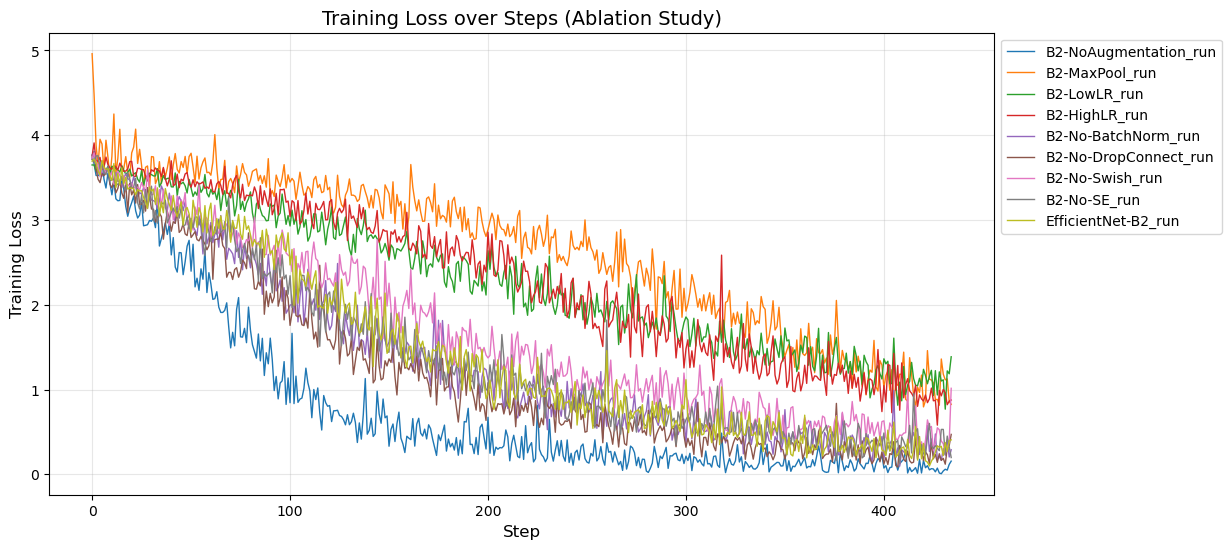

In [ ]:
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111)

for col in train_loss_step.columns:
    if col not in exclude_cols:
        ax.plot(
            range(len(train_loss_step)),
            train_loss_step[col].values,
            label=col,
            linewidth=1,
        )

ax.set_title("Training Loss over Steps (Ablation Study)", fontsize=14)
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Training Loss", fontsize=12)
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=True)
ax.grid(True, alpha=0.3)
fig.subplots_adjust(right=0.8)
plt.show()
plt.close(fig)

## Test summary for all the models


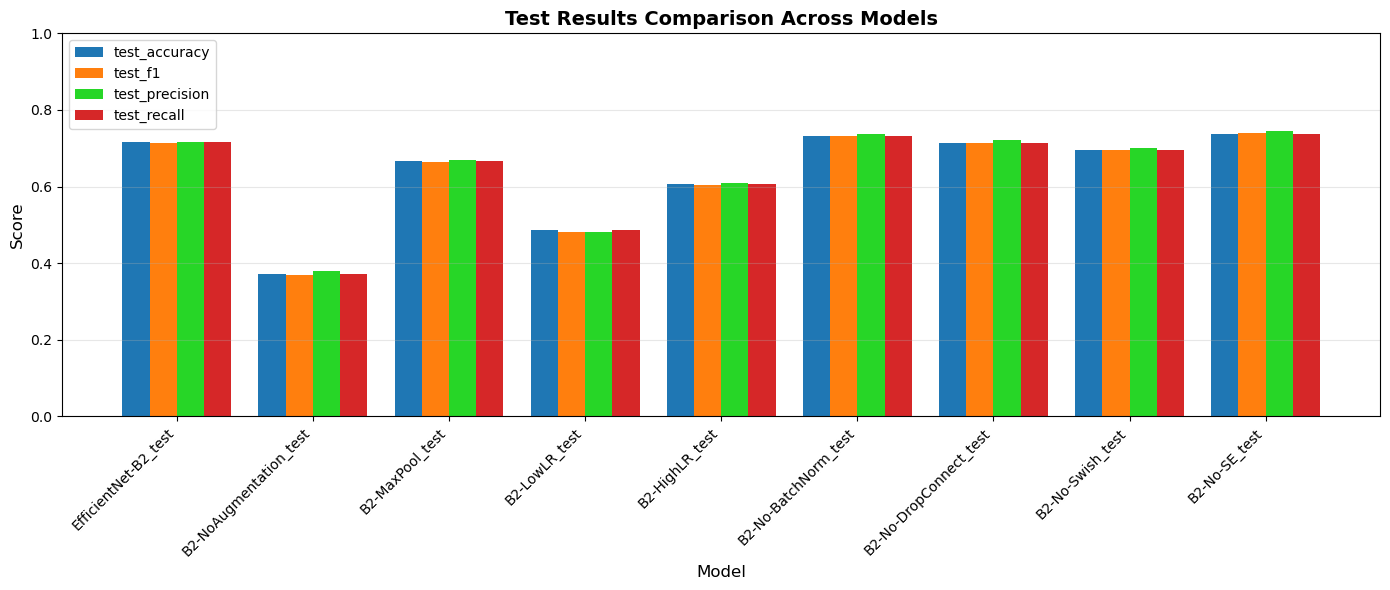

,Name,test_accuracy,test_f1,test_precision,test_recall
0,EfficientNet-B0_test,0.697725,0.696397,0.699840,0.697725
1,EfficientNet-B1_test,0.697183,0.695306,0.700818,0.697183
2,EfficientNet-B2_test,0.715601,0.714166,0.717456,0.715601
3,B2-NoAugmentation_test,0.370531,0.369881,0.379648,0.370531
4,B2-MaxPool_test,0.667389,0.664937,0.668999,0.667389
5,B2-LowLR_test,0.487541,0.481229,0.480524,0.487541
6,B2-HighLR_test,0.605634,0.603319,0.610088,0.605634
7,B2-No-BatchNorm_test,0.730769,0.731100,0.737380,0.730769
8,B2-No-DropConnect_test,0.713434,0.714310,0.721093,0.713434
9,B2-No-Swish_test,0.696100,0.695716,0.700881,0.696100


In [ ]:
test_summary = pd.read_csv("test_summary.csv", sep=";").dropna(axis=0)

test_summary_plot = test_summary[
    ~test_summary["Name"].isin(["EfficientNet-B0_test", "EfficientNet-B1_test"])
]

fig, ax = plt.subplots(figsize=(14, 6))

# Define metrics to plot
metrics = ["test_accuracy", "test_f1", "test_precision", "test_recall"]

# Get model names (index)
models = test_summary_plot["Name"]

# Set up bar positions
x = np.arange(len(models))
width = 0.2

colors = ["#1f77b4", "#ff7f0e", "#27d627", "#d62728"]
for i, metric in enumerate(metrics):
    offset = (i - 1.5) * width
    ax.bar(x + offset, test_summary_plot[metric], width, label=metric, color=colors[i])

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Test Results Comparison Across Models", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend(fontsize=10, loc="upper left")
ax.set_ylim([0, 1.0])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

test_summary

## Conclusion

The ablation study highlights **B2-No-SE** as the best-performing variant, achieving:

- validation accuracy = **0.7241**
- test accuracy = **0.7384**

Its improvement over the baseline indicates that, for this dataset and training regime, removing the Squeeze-and-Excitation (SE) blocks reduces over-specialization in channel re-weighting. This encourages the network to learn more robust and distributed feature representations, ultimately leading to better generalization.

The second-best configuration is **B2-No-BatchNorm**, achieving:

- validation accuracy = **0.7143**
- test accuracy = **0.7308**

This result suggests that eliminating batch normalization in the classification head can mitigate issues such as statistic mismatch or over-normalization of final-layer activations—particularly when using small effective batch sizes or heavy data augmentation. Preserving the discriminative scale of features appears beneficial for the final linear classifier.

All remaining ablation variants underperformed compared to the baseline **B2** model. Notably, **B2-NoAugmentation** produced the weakest results, reinforcing the importance of data augmentation as a key source of regularization and diversity for achieving strong generalization.

Overall, these findings emphasize the need for careful design of attention and normalization components, alongside maintaining robust augmentation strategies, when training EfficientNet-style models on the Oxford-IIIT Pet dataset.


## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `OxfordPetDataset`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters in order to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~90%.


# 2.A


In [ ]:
EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-3
OPTIMIZER = torch.optim.AdamW
CRITERION = nn.CrossEntropyLoss()
device = "cuda" if torch.cuda.is_available() else "cpu"

model_2A = resnet18(ResNet18_Weights.IMAGENET1K_V1)
model_2A.fc = nn.Sequential(
    nn.Linear(in_features=512, out_features=NUM_CLASSES, bias=True)
)

optimizer = OPTIMIZER(model_2A.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

train(
    model=model_2A,
    dl_train=train_dl,
    dl_val=val_dl,
    criterion=CRITERION,
    optimizer=optimizer,
    epochs=EPOCHS,
    name="resnet18",
    device="cuda" if torch.cuda.is_available() else "cpu",
    project="IPCV2",
    run_name="fine_tuning_2A",
    save_dir="./checkpoints_finetune",
)

In [29]:
evaluation_metrics_2A = test(
    model,
    test_dl,
    device=device,
)
print(evaluation_metrics_2A)

{'accuracy': 0.7248104008667389, 'precision': 0.7578334507353888, 'recall': 0.7248104008667389, 'f1': 0.7205784912299187}


# 2.A: Comments on the results

As visible from the plot below, fine tuning ResNet-18 ($\approx 11.7M$ params) with the exact same training recipe used for our custom models in part 1 do not lead to better results (even if the model is bigger and pretrained). The model overfits after around $900$ steps, reaching a maximum validation accuracy of $\approx 65\%$.


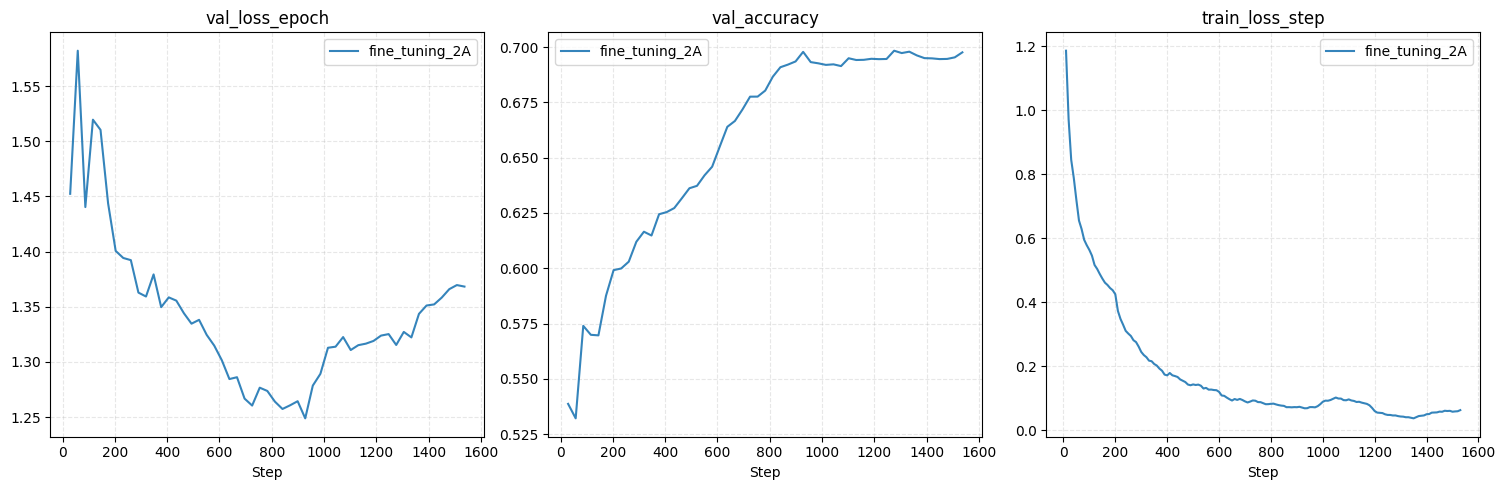

In [13]:
RUN_NAMES = ["fine_tuning_2A"]
plot_runs(RUN_NAMES)

# 2.B

Here we use the standard fine-tuning procedure defined as follows:

1. First train only the final classification FC layer with the same hyperparameters as in 2.A.
2. Then, we unfreeze all the layers and continue training the whole network with a smaller learning rate (`1e-5`)

To further decrease overfitting, we also apply label smoothing with a factor of `0.05` in the Cross Entropy Loss.


In [ ]:
EPOCHS_FC = 50
EPOCHS_FULL = 50
LR = 1e-3
LR_FULL = 1e-5
WEIGHT_DECAY = 1e-3
OPTIMIZER = torch.optim.AdamW
CRITERION = nn.CrossEntropyLoss(label_smoothing=0.05)
device = "cuda" if torch.cuda.is_available() else "cpu"

model_2B = resnet18(ResNet18_Weights.IMAGENET1K_V1)
model_2B.fc = nn.Sequential(
    nn.Linear(in_features=512, out_features=NUM_CLASSES, bias=True)
)

optimizer_fc = OPTIMIZER(model_2B.fc.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
optimizer_full = OPTIMIZER(model_2B.parameters(), lr=LR_FULL, weight_decay=WEIGHT_DECAY)


run_id = wandb.util.generate_id()

# Train only the head
model_2B.requires_grad_ = False
model_2B.fc.requires_grad_ = True

step = train(
    model=model_2B,
    dl_train=train_dl,
    dl_val=val_dl,
    criterion=CRITERION,
    optimizer=optimizer_fc,
    epochs=EPOCHS_FC,
    name="resnet18++",
    device=device,
    project="IPCV2",
    run_name="fine_tuning_2B",
    save_dir="./checkpoints_finetune",
    run_id=run_id,
)

# Train all together
model_2B.requires_grad_ = True
train(
    model=model_2B,
    dl_train=train_dl,
    dl_val=val_dl,
    criterion=CRITERION,
    optimizer=optimizer_full,
    epochs=EPOCHS_FULL,
    name="resnet18++",
    device=device,
    project="IPCV2",
    run_name="fine_tuning_2B",
    save_dir="./checkpoints_finetune",
    init_step=step,
    run_id=run_id,
)

In [30]:
evaluation_metrics_2B = test(
    model_2B,
    test_dl,
    device=device,
)
print(evaluation_metrics_2B)

{'accuracy': 0.8661971830985915, 'precision': 0.8704837611718633, 'recall': 0.8661971830985915, 'f1': 0.8659156922919578}


# 2.B: Comments on the results

As visible from the plot below, using the right procedure for fine-tuning makes a huge difference. In fact, the model reaches a val accuracy of $\approx 86\%$. It is also interesting to note that the second phase of the training (starting at around step $1500$) improves the model of about $3\%$ for val accuracy.


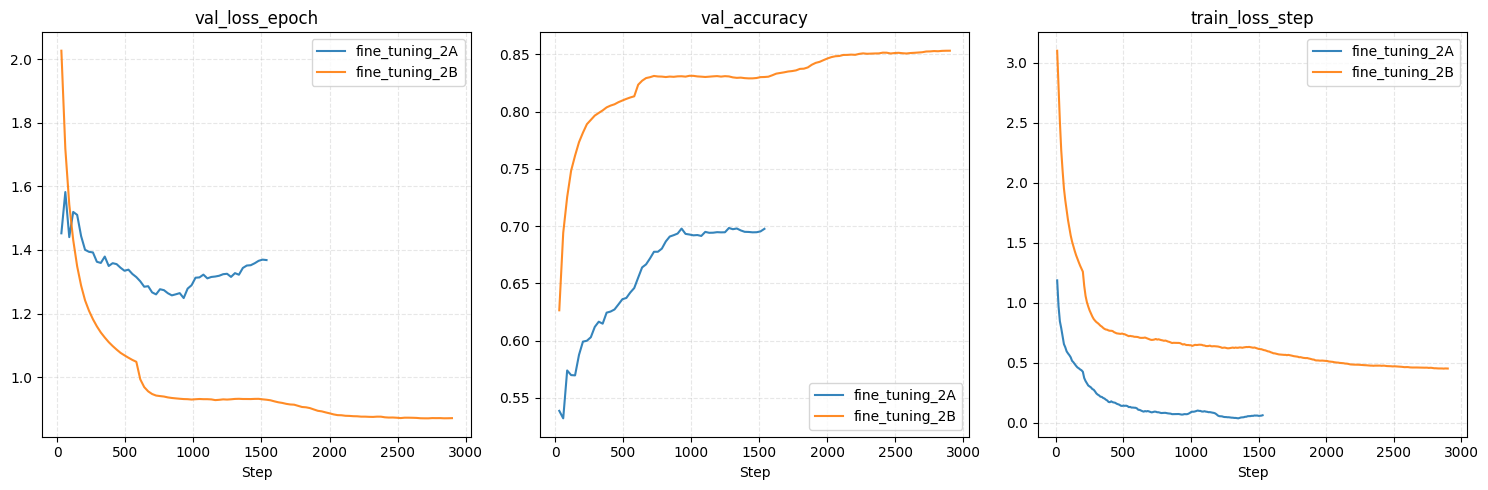

In [12]:
RUN_NAMES = ["fine_tuning_2A", "fine_tuning_2B"]
plot_runs(RUN_NAMES)